Memuat dataset...
Memulai Pelatihan...
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 6.9316
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 6.9317
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 6.9316
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 6.9317
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9316
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 6.9318
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 6.9317
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 6.9316
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 6.9316
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9317


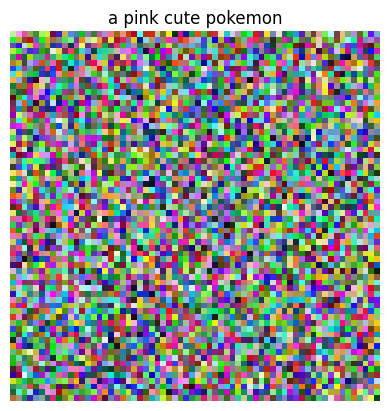

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

print("Memuat dataset...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")
all_captions = [item['text'] for item in raw_dataset]
max_tokens = 5000
seq_len = 20
text_vectorizer = layers.TextVectorization(
  max_tokens=max_tokens,
  output_sequence_length=seq_len,
)

# Adapt the text vectorizer to the captions
text_vectorizer.adapt(all_captions)

def preprocess_fn(item):
    # Proses Gambar
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0 # Normalisasi 0-1
    # Proses Teks
    caption = item['text']
    return caption, image
# Membuat generator dataset
def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

# Membuat tf.data.Dataset
train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)
# Batching dan Transformasi Teks ke Angka
train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)

# Placeholder for VQVAEEncoder - its output is currently simulated in train_step
# In a real scenario, this would be a proper VQ-VAE encoder.
class DummyVQVAEEncoder(keras.Model):
    def __init__(self):
        super().__init__()
        # No layers needed for this dummy, as its output is simulated
        pass
    def call(self, inputs):
        # This call method won't actually be used in PokemonTrainer's train_step
        # as visual_tokens are simulated. It's here for completeness.
        return tf.zeros((tf.shape(inputs)[0], 256), dtype=tf.int32)

# Placeholder for Transformer model
# In a real scenario, this would be a proper transformer architecture for image generation.
class DummyTransformer(keras.Model):
    def __init__(self, vocab_size, visual_token_vocab_size):
        super().__init__()
        # Minimal layers to satisfy the call signature. Actual transformer would be complex.
        self.text_embedding = layers.Embedding(vocab_size, 256)
        self.visual_embedding = layers.Embedding(visual_token_vocab_size, 256)
        self.dense = layers.Dense(visual_token_vocab_size)

    def call(self, inputs):
        text_tokens, vis_input = inputs

        # Embed visual input tokens
        vis_embedded = self.visual_embedding(vis_input)

        # Embed text tokens (e.g., take average for a simple context)
        text_embedded = self.text_embedding(text_tokens)

        # Simple way to combine: use the mean of text embedding as context for visual prediction
        # Broadcasting will apply text_context to each visual token position
        text_context = tf.reduce_mean(text_embedded, axis=1, keepdims=True)
        combined_features = vis_embedded + text_context

        # Pass through the dense layer to get logits for the next visual token
        preds = self.dense(combined_features)

        return preds

# Instantiate the dummy models
text_vocab_size = max_tokens # from text_vectorizer
visual_token_vocab_size = 1024 # max_val in tf.random.uniform for visual_tokens

transformer_model = DummyTransformer(text_vocab_size, visual_token_vocab_size)
vqvae_encoder = DummyVQVAEEncoder()

class PokemonTrainer(keras.Model):
    def __init__(self, transformer, vqvae_encoder):
        super().__init__()
        self.transformer = transformer
        self.vqvae_encoder = vqvae_encoder
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data
        # 1. Ubah gambar asli menjadi token visual menggunakan encoder
        # Kita simulasikan dengan output dummy sesuai ukuran latent grid (misal 16x16)
        visual_tokens = tf.random.uniform((tf.shape(images)[0], 256), minval=0, maxval=1024, dtype=tf.int32)

        # 2. Siapkan input dan target (Autoregressive)
        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]
        with tf.GradientTape() as tape:
            # Prediksi
            preds = self.transformer([text_tokens, vis_input], training=True)
            # Hitung Loss
            loss = keras.losses.sparse_categorical_crossentropy(vis_target, preds, from_logits=True)
        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
# Inisialisasi dan Compile
trainer = PokemonTrainer(transformer_model, vqvae_encoder)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))
# 5. Jalankan Training
print("Memulai Pelatihan...")
trainer.fit(train_ds, epochs=10) # Coba 10 epoch dulu

# Placeholder for generate_image_tokens function
# In a real scenario, this would involve autoregressive sampling using the transformer.
def generate_image_tokens(transformer_model_param, tokenized_text, num_visual_tokens, visual_token_vocab_size):
    # Simulate generation of visual tokens
    batch_size = tf.shape(tokenized_text)[0]
    # Start with a special token (e.g., start_of_sequence token if applicable)
    # For simplicity, we just generate random tokens for now.
    generated_tokens = tf.random.uniform((batch_size, num_visual_tokens), minval=0, maxval=visual_token_vocab_size, dtype=tf.int32)
    return generated_tokens

# Placeholder for decode_to_real_image function
# In a real scenario, this would use the VQ-VAE decoder to convert tokens back to an image.
def decode_to_real_image(generated_visual_tokens):
    # Simulate image decoding, return a random image
    # Assuming the desired output image size is 64x64x3
    return np.random.rand(64, 64, 3)

def generate_pokemon(prompt):
    # 1. Ubah teks ke angka
    tokenized_text = text_vectorizer([prompt])
    # 2. Generate token visual (Autoregressive)
    # Gunakan fungsi generate_image_tokens yang kita buat sebelumnya
    gen_vis_tokens = generate_image_tokens(transformer_model, tokenized_text, 256, 1024)
    # 3. Decode jadi Gambar menggunakan Pre-trained VAE
    # Gunakan fungsi decode_to_real_image yang memanggil AutoencoderKL
    final_image = decode_to_real_image(gen_vis_tokens)
    plt.imshow(final_image)
    plt.title(prompt)
    plt.axis("off")
    plt.show()

# TEST
generate_pokemon("a pink cute pokemon")